In [27]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import glob


In [28]:
img1 = cv2.imread('test images\IMG_4849.JPG',cv2.IMREAD_GRAYSCALE)          # queryImage
img2 = cv2.imread('test images\IMG_4850.JPG',cv2.IMREAD_GRAYSCALE) # trainImage

scale_percent = 35 # percent of original size
width = int(img1.shape[1] * scale_percent / 100)
height = int(img1.shape[0] * scale_percent / 100)
dim = (width, height)
  
# resize image
img1 = cv2.resize(img1, dim, interpolation = cv2.INTER_AREA)
img2 = cv2.resize(img2, dim, interpolation = cv2.INTER_AREA)

print(np.shape(img1))



(1411, 1058)


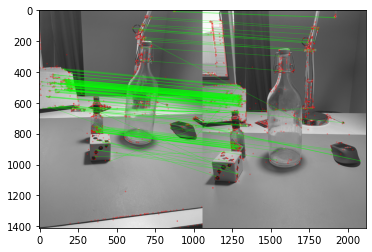

(<matplotlib.image.AxesImage at 0x2927045ff70>, None)

In [29]:


# Initiate SIFT detector
sift = cv2.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)
# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv2.FlannBasedMatcher(index_params,search_params)
matches = flann.knnMatch(des1,des2,k=2)
pts1 = []
pts2 = []
# Need to draw only good matches, so create a mask
matchesMask = [[0,0] for i in range(len(matches))]
# ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.7*n.distance:
        matchesMask[i]=[1,0]
        pts2.append(kp2[m.trainIdx].pt)
        pts1.append(kp1[m.queryIdx].pt)
draw_params = dict(matchColor = (0,255,0),
                   singlePointColor = (255,0,0),
                   matchesMask = matchesMask,
                   flags = cv2.DrawMatchesFlags_DEFAULT)
img3 = cv2.drawMatchesKnn(img1,kp1,img2,kp2,matches,None,**draw_params)
plt.imshow(img3,),plt.show()

In [30]:
pts1 = np.int32(pts1)
pts2 = np.int32(pts2)
F, mask = cv2.findFundamentalMat(pts1,pts2,cv2.FM_LMEDS)
# We select only inlier points
pts1 = pts1[mask.ravel()==1]
pts2 = pts2[mask.ravel()==1]
print(F)

def drawlines(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r,c = img1.shape
    img1 = cv2.cvtColor(img1,cv2.COLOR_GRAY2BGR)
    img2 = cv2.cvtColor(img2,cv2.COLOR_GRAY2BGR)
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        img1 = cv2.line(img1, (x0,y0), (x1,y1), color,1)
        img1 = cv2.circle(img1,tuple(pt1),5,color,-1)
        img2 = cv2.circle(img2,tuple(pt2),5,color,-1)
    return img1,img2

[[-1.19421024e-07 -4.89926867e-06  3.47853532e-03]
 [ 5.73719751e-06  4.48592599e-08 -9.81059594e-03]
 [-4.35371542e-03  9.60733484e-03  1.00000000e+00]]


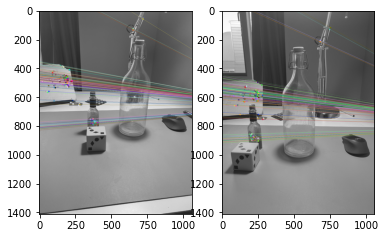

In [31]:
# Find epilines corresponding to points in right image (second image) and
# drawing its lines on left image
lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2,F)
lines1 = lines1.reshape(-1,3)
img5,img6 = drawlines(img1,img2,lines1,pts1,pts2)
# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1,1,2), 1,F)
lines2 = lines2.reshape(-1,3)
img3,img4 = drawlines(img2,img1,lines2,pts2,pts1)
plt.subplot(121),plt.imshow(img5)
plt.subplot(122),plt.imshow(img3)
plt.show()

In [32]:
calib_img = cv2.imread('Caliberation Images/trial 2/IMG_4839.JPG')


scale_percent = 35 # percent of original size
width = int(calib_img.shape[1] * scale_percent / 100)
height = int(calib_img.shape[0] * scale_percent / 100)
dim = (width, height)
  
# resize image
calib_imgg = cv2.resize(calib_img, dim, interpolation = cv2.INTER_AREA)

# cv2.imshow('img',calib_imgg)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

This one

In [33]:
#Define size of chessboard target.
chessboard_size = (8,5)

#Define arrays to save detected points
obj_points = [] #3D points in real world space 
img_points = [] #3D points in image plane
#Prepare grid and points to display
objp = np.zeros((np.prod(chessboard_size),3),dtype=np.float32)
objp[:,:2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1,2)
objp = objp * 0.03



In [34]:
folderpath = 'Caliberation Images/trial 2'
calibration_paths = glob.glob(f'{folderpath}/*.jpg')
#Iterate over images to find intrinsic matrix
print(calibration_paths[0])
for fname in calibration_paths:
    
    img = cv2.imread(fname)
    img = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
    # cv2.imshow('img',img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()


Caliberation Images/trial 2\IMG_4839.JPG


In [35]:
#read images
calibration_paths = glob.glob('Caliberation Images/*.jpg')
#Iterate over images to find intrinsic matrix
for image_path in calibration_paths:
  #Load image
  image = cv2.imread(image_path)
  img = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  print("Image loaded, Analizying...")
  #find chessboard corners
  ret,corners = cv2.findChessboardCorners(gray_image, chessboard_size, None)
  if ret == True:
    print("Chessboard detected!")
    print(image_path)
    #define criteria for subpixel accuracy
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    #refine corner location (to subpixel accuracy) based on criteria.
    cv2.cornerSubPix(gray_image, corners, (5,5), (-1,-1), criteria)
    obj_points.append(objp)
    img_points.append(corners)

Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4826.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4827.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4828.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4829.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4830.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4831.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4832.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4833.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4834.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4835.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4836.JPG
Image loaded, Analizying...
Chessboard detected!
Caliberation Images\IMG_4837.JPG
Image loaded, An

In [36]:
#Calibrate camera
ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(obj_points, img_points,gray_image.shape[::-1], None, None) 
# print("Camera matrix : \n")
# print(K)
# print("dist : \n")
# print(dist)
# print("rvecs : \n")
# print(rvecs)
# print("tvecs : \n")
print(tvecs[0])

[[-0.09706039]
 [ 0.10312471]
 [ 0.75488054]]


In [37]:
random =np.zeros((3,4))
random[:3,:3] = cv2.Rodrigues(rvecs[0])[0]
random[:3,3] = tvecs[0].transpose()
print(random)

[[ 1.01495021e-02  9.98367456e-01 -5.62086283e-02 -9.70603934e-02]
 [-9.84503860e-01  1.35539771e-04 -1.75362854e-01  1.03124706e-01]
 [-1.75068948e-01  5.71174572e-02  9.82897990e-01  7.54880542e-01]]


In [38]:
R = cv2.Rodrigues(rvecs[0])[0]
t = tvecs[0]
Rt = np.concatenate([R,t], axis=-1) # [R|t]
P = np.matmul(K,Rt) # A[R|t]
print(P)

[[-2.38039857e+02  3.12590543e+03  1.33879460e+03  8.64216009e+02]
 [-3.33034356e+03  1.13767836e+02  1.41936885e+03  1.81061266e+03]
 [-1.75068948e-01  5.71174572e-02  9.82897990e-01  7.54880542e-01]]


In [39]:
def FindProjectionMatrix(rotationMatrix,translationVector,K):
    if(np.shape(rotationMatrix)!=(3,3)):
        R = cv2.Rodrigues(rotationMatrix[0])[0]
        print('debug')
    R =rotationMatrix
    Rt = np.concatenate([R,translationVector], axis=-1) # [R|t]
    P = np.matmul(K,Rt) # A[R|t]
    return P

In [40]:
img = cv2.imread('Caliberation Images\IMG_4826.JPG')
img = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
h,  w = img.shape[:2]
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w,h), 1, (w,h))
# undistort
dst = cv2.undistort(img, K, dist, None, newcameramtx)
# crop the image
x, y, w, h = roi
dst = dst[y:y+h, x:x+w]
cv2.imshow('undistorted',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [41]:
E =np.matmul(np.transpose(K),F,K)
print(E)


[[-3.63414234e-04 -1.49091333e-02  1.05856507e+01]
 [ 1.73828303e-02  1.35916691e-04 -2.97246040e+01]
 [ 6.84906965e-03  2.17052057e-03 -1.31269965e+01]]


In [42]:
print(cv2.decomposeEssentialMat(E)[2])

[[-0.1311233 ]
 [ 0.36104499]
 [-0.92328392]]


In [53]:
Basepair_2 =FindProjectionMatrix(cv2.decomposeEssentialMat(E)[0],cv2.decomposeEssentialMat(E)[2],K)
print(Basepair_2)

[[ 1.05836752e+01 -2.03715896e-01 -2.33038416e-02 -9.77889628e+00]
 [-2.97181333e+01  6.16827635e-01  6.68185038e-02  2.74420187e+01]
 [-1.31241856e+01  2.70138385e-01  2.94385747e-02  1.21198304e+01]]


In [54]:
#Basepair_1 = FindProjectionMatrix(np.ones_like(cv2.decomposeEssentialMat(E)[1]),np.ones_like(cv2.decomposeEssentialMat(E)[2]),K)
#Basepair_1 = FindProjectionMatrix(np.eye(3),np.zeros_like(cv2.decomposeEssentialMat(E)[2]),K)
Basepair_1 = np.eye(4)
print(Basepair_1)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [55]:
print(K)

[[-3.63414234e-04 -1.49091333e-02  1.05856507e+01]
 [ 1.73828303e-02  1.35916691e-04 -2.97246040e+01]
 [ 6.84906965e-03  2.17052057e-03 -1.31269965e+01]]


In [56]:
left_point_t = np.array(img1).transpose()
right_point_t =np.array(img2).transpose()
triangulation  =cv2.triangulatePoints(Basepair_1[:3],Basepair_2[:3],pts1[:5].transpose(),pts2[:5].transpose())



In [57]:
print ('3d\n', triangulation[:5])
print ('pts1\n', pts1[:5].transpose())
print ('pts2\n', pts2[:5].transpose())

3d
 [[  802320668 -1094203034   802320668 -1094203034   802320668]
 [-1094203034   802320668 -1094203034   802320668 -1094203034]
 [ 1054758446  -692957802  1054758446  -692957802  1054758446]
 [-1074790407  -732388715 -1074790407  -732388715 -1074790407]]
pts1
 [[ 18  18  22  47  47]
 [464 464 489 559 559]]
pts2
 [[ 82  82  80  87  87]
 [566 566 589 656 656]]


In [58]:

print(triangulation[:5][:][:][2]/triangulation[:5][:][:][3])

[-0.98136198  0.94616122 -0.98136198  0.94616122 -0.98136198]


In [49]:
# Camera projection matrices
P1 = np.eye(4)
P2 = np.array([[ 0.878, -0.01 ,  0.479, -1.995],
            [ 0.01 ,  1.   ,  0.002, -0.226],
            [-0.479,  0.002,  0.878,  0.615],
            [ 0.   ,  0.   ,  0.   ,  1.   ]])
# Homogeneous arrays
a3xN = np.array([[ 0.091,  0.167,  0.231,  0.083,  0.154],
              [ 0.364,  0.333,  0.308,  0.333,  0.308],
              [ 1.   ,  1.   ,  1.   ,  1.   ,  1.   ]])
b3xN = np.array([[ 0.42 ,  0.537,  0.645,  0.431,  0.538],
              [ 0.389,  0.375,  0.362,  0.357,  0.345],
              [ 1.   ,  1.   ,  1.   ,  1.   ,  1.   ]])
# The cv2 method
X = cv2.triangulatePoints( P1[:3], P2[:3], a3xN[:2], b3xN[:2] )
# Remember to divide out the 4th row. Make it homogeneous
X /= X[3]
# Recover the origin arrays from PX
x1 = np.dot(P1[:3],X)
x2 = np.dot(P2[:3],X)
# Again, put in homogeneous form before using them
x1 /= x1[2]
x2 /= x2[2]
 
print ('X\n', X)
print ('x1\n', x1)
print ('x2\n', x2)

X
 [[ 1.00277401  2.00861221  3.01259262  1.00350119  2.01054271]
 [ 4.01217993  4.01031008  4.01743742  4.02958919  4.01894571]
 [11.01977924 12.02856882 13.04163081 12.09159201 13.05497299]
 [ 1.          1.          1.          1.          1.        ]]
x1
 [[0.09099765 0.1669868  0.23099815 0.08299165 0.15400589]
 [0.36408896 0.33339877 0.30804717 0.33325547 0.30784788]
 [1.         1.         1.         1.         1.        ]]
x2
 [[0.42002058 0.53709198 0.64501084 0.43105651 0.5379664 ]
 [0.38890031 0.37453153 0.36194222 0.35671333 0.34517832]
 [1.         1.         1.         1.         1.        ]]


In [50]:
print(pts1[0].transpose())
print(a3xN[:2])


[ 18 464]
[[0.091 0.167 0.231 0.083 0.154]
 [0.364 0.333 0.308 0.333 0.308]]


In [51]:
corr_img =cv2.imread('test images\IMG_4849.JPG')
corr_img = cv2.resize(corr_img, dim, interpolation = cv2.INTER_AREA)
for point in pts1[:5]:
    circle_image_1 = cv2.circle(corr_img, (point[0],point[1]), 20, (255, 0, 0), 5)

cv2.imshow('result',circle_image_1)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [52]:
corr_img_2 =cv2.imread('test images\IMG_4850.JPG')
corr_img_2 = cv2.resize(corr_img_2, dim, interpolation = cv2.INTER_AREA)
for point in pts2[:5]:
    circle_image_2 = cv2.circle(corr_img, (point[0],point[1]), 20, (255, 0, 0), 5)

cv2.imshow('result',circle_image_2)
cv2.waitKey(0)
cv2.destroyAllWindows()